In [1]:
import os
os.chdir(r"C:\Users\Annie.LAPTOP-NJ5KV9M1\AGN_mapping")

In [2]:
pip install astropy scipy matplotlib numpy h5py tqdm numba pint-pulsar emcee corner statsmodels pyfftw tbb

Note: you may need to restart the kernel to use updated packages.


In [3]:
pip install pytest pytest-astropy jinja2 docutils sphinx-astropy nbsphinx pandoc ipython jupyter notebook towncrier tox black

In [4]:
pip install stingray PyROA emcee tabulate corner astropy

Note: you may need to restart the kernel to use updated packages.


In [5]:
import shutil

# Replace '/path/to/work_directory' with your actual work directory

src = r'C:\Users\Annie.LAPTOP-NJ5KV9M1\AGN_mapping\CPython\PYCCF.py'
dst = r'PYCCF.py'
dst2 = r'xcorspc.pyx'

shutil.copy(src, dst)
shutil.copy(src, dst2)

'xcorspc.pyx'

In [6]:
import os
print(os.getcwd())

C:\Users\Annie.LAPTOP-NJ5KV9M1\AGN_mapping


In [7]:
import numpy as np
import matplotlib.pyplot as plt
import os
import sys
import argparse
import random

from scipy import stats
import scipy.integrate as integrate

from stingray import Lightcurve, Crossspectrum, AveragedCrossspectrum

import PYCCF as myccf
import PyROA
import psi

import importlib
importlib.reload(psi)


<module 'psi' from 'C:\\Users\\Annie.LAPTOP-NJ5KV9M1\\AGN_mapping\\psi.py'>

In [8]:
import scipy
print(scipy.__version__)
print(scipy.__file__)

1.15.2
c:\Users\Annie.LAPTOP-NJ5KV9M1\miniconda3\envs\agn\lib\site-packages\scipy\__init__.py


In [9]:
#import AGN light curve
directory_path = r'C:\Users\Annie.LAPTOP-NJ5KV9M1\AGN_mapping\data'
file_path = os.path.join(directory_path, 'lc30mins.dat')

column_index1 = 0  
column_index2 = 1

with open(file_path, 'r') as file:
    # Read all lines
    lines = file.readlines()
    data_lines = lines[1:]
    
   # Extract the desired columns from each line and convert to float
    column1_data = [float(line.split()[column_index1]) for line in data_lines]
    column2_data = [float(line.split()[column_index2]) for line in data_lines]

time = np.array(column1_data)/(24*3600)
flux = np.array(column2_data)

dt = 1800 #each interval in seconds 

exposure = len(time) #length of full array 
seconds_day = 86400
original_length = exposure/(seconds_day/dt)

#times = (np.linspace(-exposure, exposure+1, num = exposure*2)*dt)/(24*3600) # converted to days
times = (np.linspace(1, exposure+1, num = exposure)*dt)/(24*3600)

#define disk function
def disk(times,wavelength):
    bhmass = 10**7.7       # Msol
    mdot = 0.5         # Msol/yr
    inc = 45           # inclination, degrees
    combi_psi = psi.pytfb_sub(times,1e8,mdot,wavelength,inc,norm=1)
    combi_psi[np.isnan(combi_psi)]=0
    # normalise 
    normi = np.trapz(combi_psi,x=times)
    return (combi_psi/normi)


combi_psi_1 = disk(times, 4770)


## below checking the disk response function to see if it is normalised


In [27]:
# integrate disk response function

normalisation = np.trapz(combi_psi_1, times)
mean_lag = np.trapz(times * combi_psi_1, x=times)

print("Integral =", normalisation)
print("Mean lag =", mean_lag)

Integral = 0.9999999999999999
Mean lag = 2.0461672863726563


In [49]:
psi_norm = combi_psi_1 / np.sum(combi_psi_1)

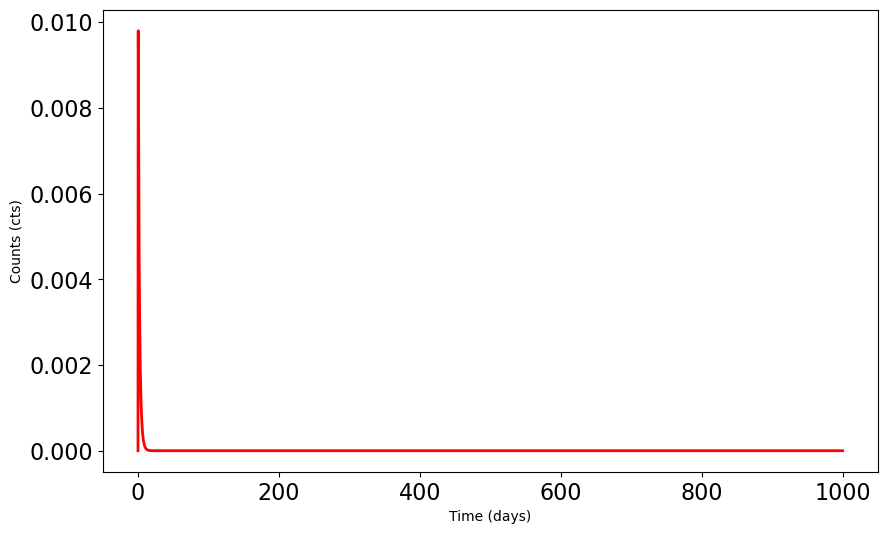

In [50]:
#plot of PSD based light curve
fig, ax = plt.subplots(1,1,figsize=(10,6))
ax.plot(times, psi_norm, lw=2, color='red')
#ax.set_xlim(-10,100)
ax.set_xlabel("Time (days)")
ax.set_ylabel("Counts (cts)")
ax.tick_params(axis='x', labelsize=16)
ax.tick_params(axis='y', labelsize=16)
plt.show()

In [39]:
print(len(times))
print(len(time))



48000
48000


In [51]:
signal_DISK = np.convolve(flux, psi_norm, mode='full')

#start_index2 = int((len(signal_DISK) - len(flux)) / 2)
#end_index2 = start_index2 + len(flux)
#signal_DISK = signal_DISK[start_index2:end_index2]

zero_idx = np.argmin(np.abs(times))
signal_DISK = signal_DISK[zero_idx:zero_idx + len(flux)]


In [52]:

lc_DISK = Lightcurve(times, signal_DISK)
lc = Lightcurve(time,flux)

c:\Users\Annie.LAPTOP-NJ5KV9M1\miniconda3\envs\agn\lib\site-packages\stingray\lightcurve.py:329: UserWarning: On Windows, the size of an integer is 32 bits. To avoid integer overflow, I'm converting the input array to float
  warnings.warn(


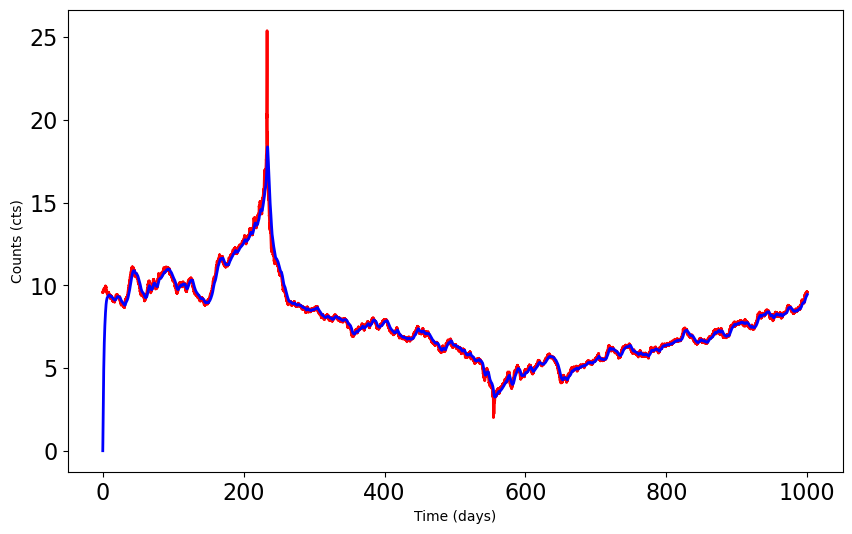

In [54]:
#plot of PSD based light curve
fig, ax = plt.subplots(1,1,figsize=(10,6))
ax.plot(lc.time, lc.counts, lw=2, color='red')
ax.plot(lc_DISK.time, lc_DISK.counts, lw=2, color='blue')
ax.set_xlabel("Time (days)")
ax.set_ylabel("Counts (cts)")
ax.tick_params(axis='x', labelsize=16)
ax.tick_params(axis='y', labelsize=16)
plt.show()

In [15]:
expected_index = len(combi_psi_1) // 2
print("Expected index of the peak:", expected_index)    

Expected index of the peak: 24000


In [16]:
np.argmax(combi_psi_1)


16

In [17]:
import sys
import argparse
import PYCCF as myccf

#########################################
##Set Interpolation settings, user-specified
#########################################
lag_range = [-100, 100]  #Time lag range to consider in the CCF (days). Must be small enough that there is some overlap between light curves at that shift (i.e., if the light curves span 80 days, these values must be less than 80 days)
interp = 0.2 #Interpolation time step (days). Must be less than the average cadence of the observations, but too small will introduce noise.
nsim = 300  #Number of Monte Carlo iterations for calculation of uncertainties
mcmode = 0  #Do both FR/RSS sampling (1 = RSS only, 2 = FR only) 
sigmode = 0.2  #Choose the threshold for considering a measurement "significant". sigmode = 0.2 will consider all CCFs with r_max <= 0.2 as "failed". See code for different sigmodes.


In [ ]:
#cc = CrossCorrelation(lc4, )


NameError: name 'CrossCorrelation' is not defined

In [ ]:
wavelengths = [2000, 3000, 4000, 5000, 6000]

lags_out = []

for wl in wavelengths:
    psi_disk = disk(times, wl, 1)
    disk_lc = fftconvolve(flux, psi_disk, mode='same')
    
    lags, r, centroid, peak = iccf(time, flux, time, disk_lc)
    lags_out.append(centroid)

: 

: 

: 

##testing shakura-sunyaev wavelength lag dependancy 